In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [6]:
path = "../../outputs/"

In [7]:
r_1s_U = np.loadtxt(path + "autocorr/autocorr_r100_U.dat")
r_2p_U = np.loadtxt(path + "autocorr/autocorr_r210_U.dat")
r_1s_G = np.loadtxt(path + "autocorr/autocorr_r100_G.dat")
r_2p_G = np.loadtxt(path + "autocorr/autocorr_r210_G.dat")

In [8]:
# Compute autocorrelation function
def compute_autocorrelation(x, max_lag):
    n = len(x)
    mean = np.mean(x)
    var = np.var(x)
    
    x_centered = x - mean
    
    acf = np.zeros(max_lag)
    for tau in range(max_lag):
        # Sum of x(t) * x(t+tau)
        # Equivalent of c++
            # double sum = 0;
            #for(int t = 0; t < n - tau; t++) {
            #    sum += x[t] * x[t + tau];
            #}
        sum_prod = np.sum(x_centered[:n-tau] * x_centered[tau:])
        
        # Divide for the number of summed terms (number of pairs at distance tau: n-tau) and for the variance
        acf[tau] = (sum_prod / (n - tau)) / var
        
    return acf



# Exponential decay function for fitting
def exponential_decay(tau, tau_c):
    return np.exp(-tau / tau_c)

In [9]:
# Max delay for which we compute the autocorrelation function
max_tau = 300 # steps (usually sufficient to see the decay)
lags = np.arange(max_tau)

acf1s_U = compute_autocorrelation(r_1s_U, max_tau)
acf2p_U = compute_autocorrelation(r_2p_U, max_tau)
acf1s_G = compute_autocorrelation(r_1s_G, max_tau)
acf2p_G = compute_autocorrelation(r_2p_G, max_tau)

acfs = [acf1s_U, acf2p_U, acf1s_G, acf2p_G]
labels = ["1s state (Uniform)", "2p state (Uniform)", "1s state (Gaussian)", "2p state (Gaussian)"]


Exponential Fit Results for Correlation Times:
[1s state (Uniform)] -> Estimated tau_c: 193.0 steps
[2p state (Uniform)] -> Estimated tau_c: 14.7 steps
[1s state (Gaussian)] -> Estimated tau_c: 75.2 steps
[2p state (Gaussian)] -> Estimated tau_c: 15.7 steps



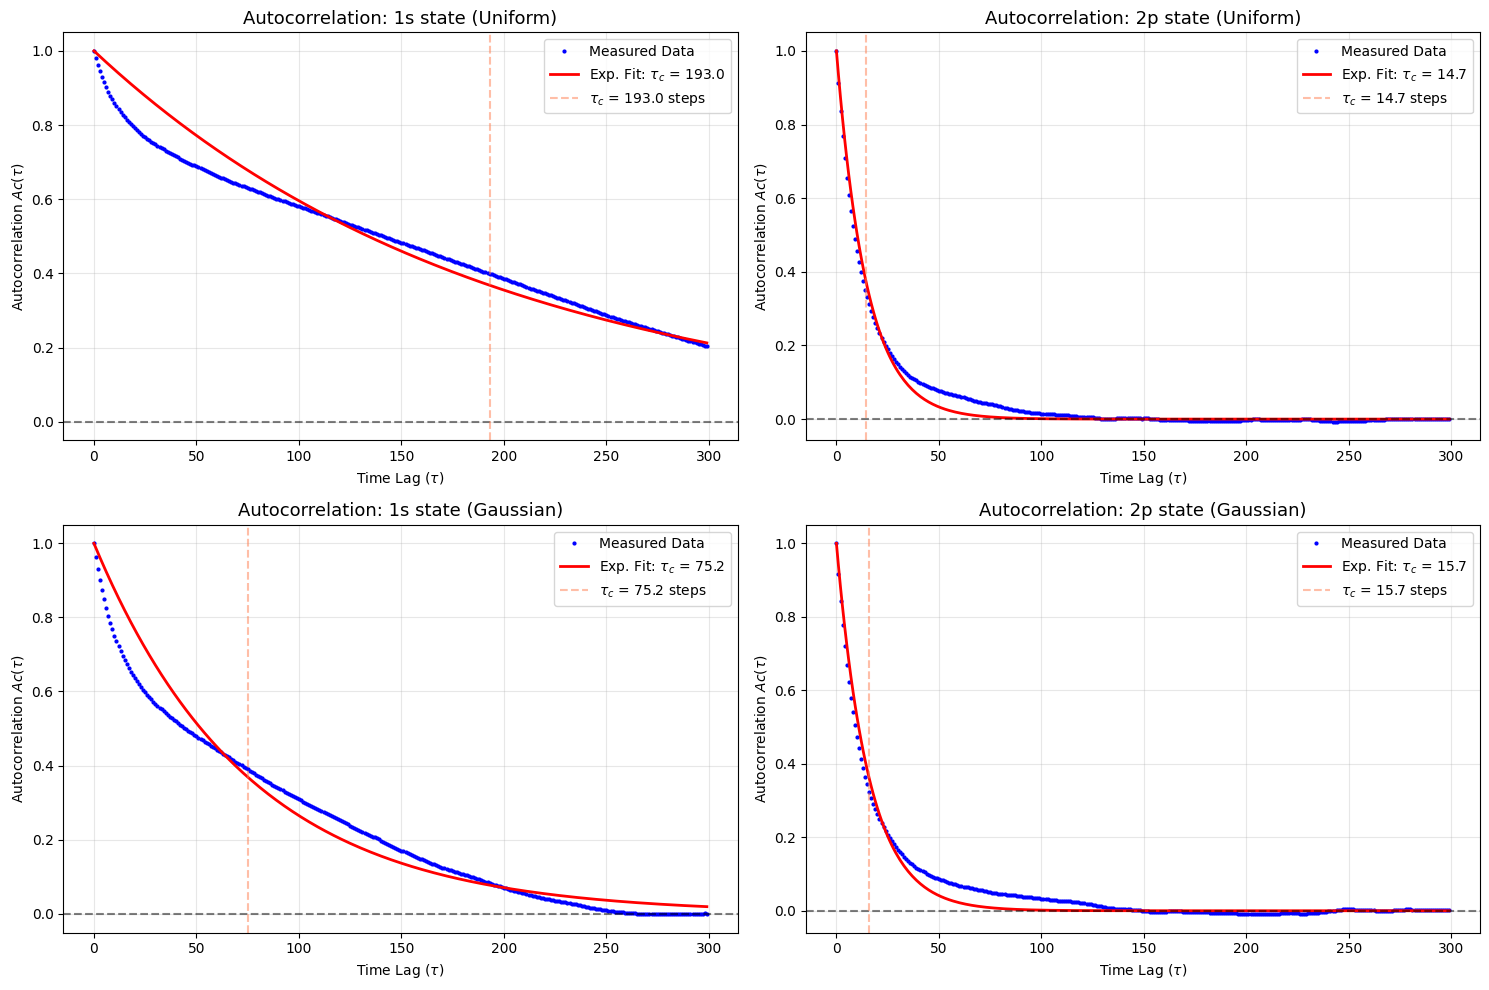

In [10]:
# Fit the data to the exponential curve and plot results

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2D array of axes into a 1D array for easy iteration

print("\nExponential Fit Results for Correlation Times:")
print("=" * 60)

# Loop simultaneously through the ACFs, their labels, and their designated subplot axis (ax)
for acf, label, ax in zip(acfs, labels, axes):

    # Perform the exponential fit (starting from index 1 to avoid tau=0 where Ac=1 perfectly)
    popt, pcov = curve_fit(exponential_decay, lags[1:], acf[1:])
    tau_c = popt[0]

    # Print result to console
    print(f"[{label}] -> Estimated tau_c: {tau_c:.1f} steps")

    # Plot the data and the fit
    ax.plot(lags, acf, label="Measured Data", marker='.', linestyle='none', markersize=4, color='blue')
    ax.plot(lags, exponential_decay(lags, tau_c), label=f"Exp. Fit: $\\tau_c$ = {tau_c:.1f}", color='red', linewidth=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(tau_c, color='coral', linestyle='--', alpha=0.5, label=f"$\\tau_c$ = {tau_c:.1f} steps")

    # 3. Format the subplot
    ax.set_title(f"Autocorrelation: {label}", fontsize=13)
    ax.set_xlabel("Time Lag ($\\tau$)")
    ax.set_ylabel("Autocorrelation $Ac(\\tau)$")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

print("=" * 60, "\n")

plt.tight_layout()
plt.show()

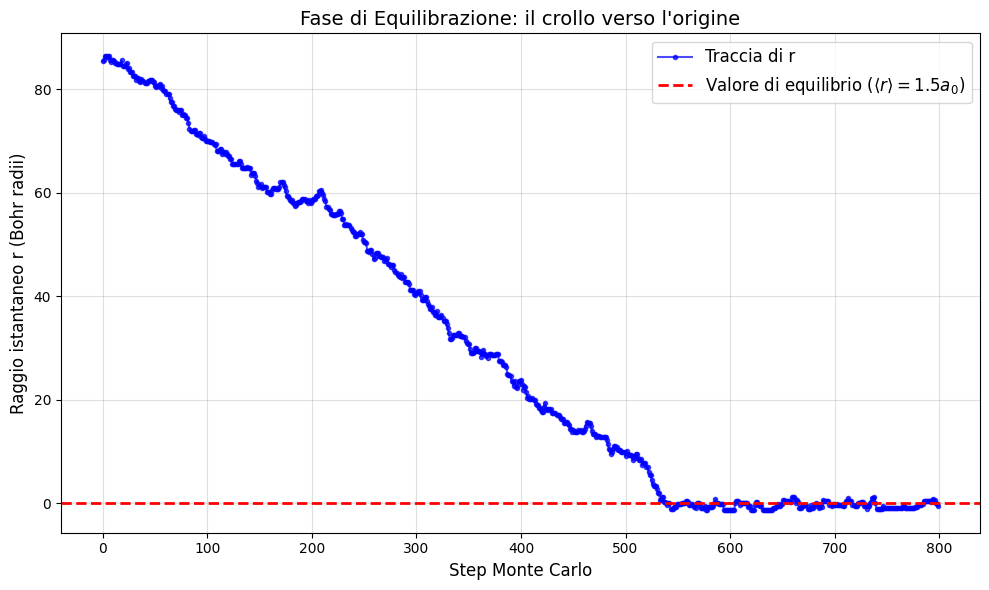

In [12]:
# 1. Carica i dati appena generati (quelli in cui hai spento l'equilibrazione in C++)
# Assicurati che il percorso sia corretto
r_1s_U = np.loadtxt(path + "autocorr/autocorr_r100_U.dat")

# 2. Seleziona solo i primissimi step! 
# Questo è il segreto: guardiamo solo i primi 500 passi su 500.000
steps_to_show = 800
steps = np.arange(steps_to_show)
r_iniziale = r_1s_U[:steps_to_show] -1.5

# 3. Plot della fase di equilibrazione
plt.figure(figsize=(10, 6))

# Plottiamo la traiettoria collegando i punti per vedere il "cammino"
plt.plot(steps, r_iniziale, marker='.', linestyle='-', color='blue', alpha=0.7, label='Traccia di r')

# Disegniamo una linea rossa sul valore atteso (1.5 per lo stato 1s)
plt.axhline(0.0, color='red', linestyle='--', linewidth=2, label="Valore di equilibrio ($\\langle r \\rangle = 1.5 a_0$)")

plt.title("Fase di Equilibrazione: il crollo verso l'origine", fontsize=14)
plt.xlabel("Step Monte Carlo", fontsize=12)
plt.ylabel("Raggio istantaneo r (Bohr radii)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [16]:
dist = np.abs(r_iniziale[550:])
np.max(dist)

np.float64(1.291818)